In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error

import warnings
warnings.filterwarnings('ignore')

In [2]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"

df = pd.read_csv(url)

df.head()

,Month,Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [3]:
print(df.shape)

print(df.head())

(144, 2)
     Month  Passengers
0  1949-01         112
1  1949-02         118
2  1949-03         132
3  1949-04         129
4  1949-05         121


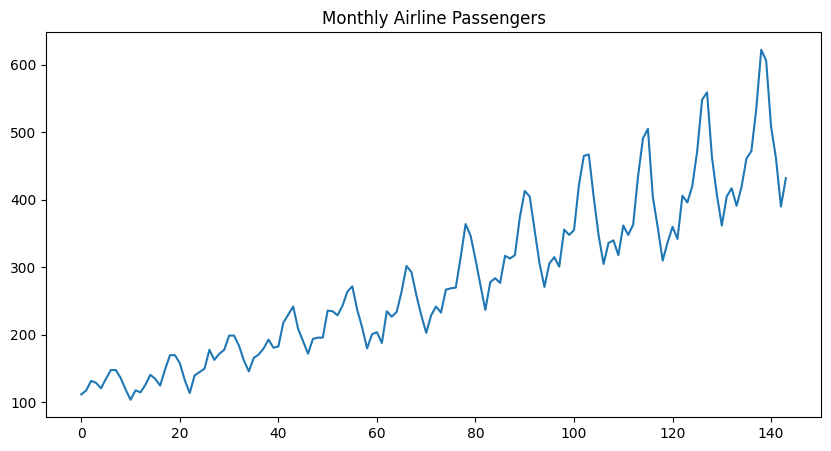

In [4]:
data = df['Passengers']

plt.figure(figsize=(10,5))
plt.plot(data)
plt.title("Monthly Airline Passengers")
plt.show()

In [5]:
train_size = int(len(data)*0.8)

train = data[:train_size]

test = data[train_size:]

In [6]:
model = SARIMAX(
    train,
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)

model_fit = model.fit()

In [7]:
forecast = model_fit.forecast(
    steps=len(test)
)

print(forecast)

115    489.724155
116    429.406225
117    372.216572
118    331.836692
119    362.700073
120    367.719967
121    346.377664
122    392.239401
123    378.877956
124    392.923852
125    464.526840
126    519.093192
127    518.443860
128    457.515264
129    400.175596
130    359.358950
131    390.182760
132    394.896669
133    373.285208
134    418.508775
135    404.906192
136    419.299985
137    491.038046
138    546.117050
139    545.242942
140    484.532634
141    427.245257
142    386.584268
143    417.421735
Name: predicted_mean, dtype: float64


In [8]:
rmse = np.sqrt(
    mean_squared_error(
        test,
        forecast
    )
)

print("RMSE =", rmse)

RMSE = 30.142008134932393


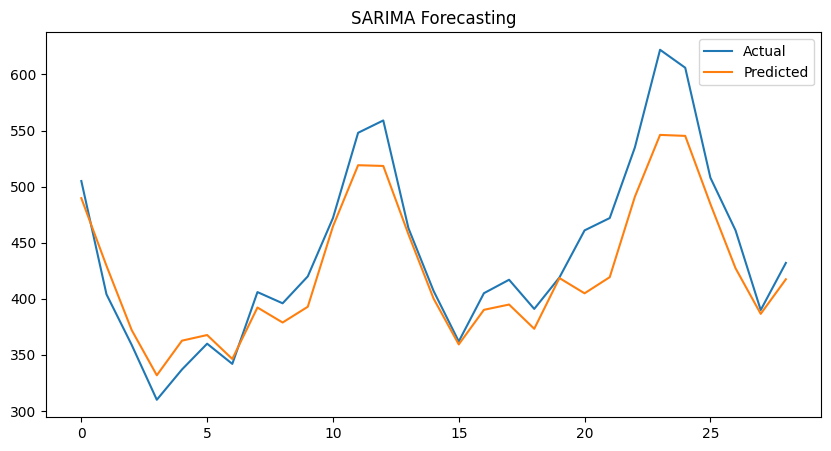

In [9]:
plt.figure(figsize=(10,5))

plt.plot(
    test.values,
    label='Actual'
)

plt.plot(
    forecast.values,
    label='Predicted'
)

plt.legend()

plt.title(
    "SARIMA Forecasting"
)

plt.show()